In [28]:
#imports
import sys
import os

# Adds the parent directory to the search path
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import xtrack as xt
import xpart as xp
import xobjects as xo


In [29]:
#read in file
df = pd.read_csv('PositronBeam_2p86GeV/Beam_3GHzOption_2.86GeV_20260421.dat', sep=r'\s+')
print(list(df.columns))

['x[mm]', 'xp[mrad]', 'y[mm]', 'yp[mrad]', 't[mm/c]', 'p[MeV/c]', 'ID']


In [30]:

def CalcEmittanceManual(df, position, angle):
    pos = df[position].values
    ang = df[angle].values

    x_c = pos - np.mean(pos)
    xp_c = ang - np.mean(ang)

    x2_mean = np.mean(x_c**2)
    xp2_mean = np.mean(xp_c**2)
    xxp_mean = np.mean(x_c * xp_c)
    
    emittance = np.sqrt(x2_mean * xp2_mean - xxp_mean**2)
    return emittance

def CalcEmittanceAuto(df, position, angle):
    pos = df[position].values
    ang = df[angle].values
    
    cov = np.cov(pos, ang, ddof=0) 
    emittance = np.sqrt(np.linalg.det(cov))
    return emittance


def NormalisedEmittance(emittance, E_total_mev):
    # Electron/Positron rest mass in MeV
    m0 = 0.510998 
    
    gamma_rel = E_total_mev / m0
    beta_rel = np.sqrt(1 - 1/gamma_rel**2)
    
    n_emittance = beta_rel * gamma_rel * emittance
    return n_emittance

def get_twiss(df, position, angle, p_col='p[MeV/c]', p0_mev=2860.0):
    pos = df[position].values
    ang = df[angle].values
    
    # Calculate emittance 
    eps = CalcEmittanceAuto(df, position, angle)
    
    cov_matrix = np.cov(pos, ang, ddof=0)
    
    beta = cov_matrix[0, 0] / eps
    alpha = -cov_matrix[0, 1] / eps
    gamma = (1 + alpha**2) / beta
    
    # Dispersion calculation
    delta = (df[p_col].values - p0_mev) / p0_mev
    dispersion_x = np.cov(pos, delta, ddof=0)[0, 1] / np.var(delta)
    disp_prime_x = np.cov(ang, delta, ddof=0)[0, 1] / np.var(delta)
    
    return alpha, beta, gamma, dispersion_x, disp_prime_x



def plot_twiss_ellipse(beta, alpha, beta2, alpha2, emittance,ax):
    gamma = (1 + alpha**2) / beta
    theta = np.linspace(0, 2*np.pi, 100)
    
    x1 = np.sqrt(emittance * beta) * np.cos(theta)
    xp1 = -np.sqrt(emittance / beta) * (alpha * np.cos(theta) - np.sin(theta))
    x2 = np.sqrt(emittance * beta2) * np.cos(theta)
    xp2 = -np.sqrt(emittance / beta2) * (alpha2 * np.cos(theta) - np.sin(theta))
    
    #ax.figure(figsize=(6,6))
    ax.plot(x1, xp1, label=f'Particle distribution',color='blue')#: α={alpha:.2f}, β={beta:.2f} m',color='blue')
    ax.plot(x2, xp2, label=f'Initial ring parameters',color='red')#: α={alpha2:.2f}, β={beta2:.2f} m',color='red')
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.axvline(0, color='black', lw=0.5, ls='--')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    ax.axis('equal')

def normalisation_matrix(beta_r,alpha,beta_l,phi,x,xp):
    mat_A=np.array([
        [np.sqrt(beta_r),0],
        [-alpha/np.sqrt(beta_l),1/np.sqrt(beta_r)]
        ])

    mat_B=np.array([
        [np.cos(phi),np.sin(phi)],
        [-np.sin(phi),np.cos(phi)]
    ])

    mat_C=np.array([
        [1/np.sqrt(beta_l),0],
        [alpha/np.sqrt(beta_l),np.sqrt(beta_l)]
    ])

    x_col=np.array([
        [x],[xp]
    ])

    result=mat_A @ mat_B @ mat_C @ x_col

    zeta=result[0,0]
    zeta_prime=result[1,0]
    
    return zeta, zeta_prime

def plot_twiss_ellipse_normalised(beta_l,alpha_l,beta_r, alpha_r,disp,ddisp,delta,emittance,ax):

    phi=np.linspace(0,2*np.pi,500)

    x = np.sqrt(emittance * beta_l) * np.cos(phi)
    xp = - (np.sqrt(emittance / beta_l)) * (alpha_l * np.cos(phi) + np.sin(phi))


    zeta=(1/(np.sqrt(beta_l)))*x
    zeta_prime=np.sqrt(beta_l)*xp+(alpha_l/np.sqrt(beta_l))*x

    zeta_r=(1/(np.sqrt(beta_r)))*x
    zeta_prime_r=np.sqrt(beta_r)*xp+(alpha_r/np.sqrt(beta_r))*x

    x_b=x+disp*delta
    xp_b=xp+ddisp*delta

    print(disp*delta)


    zeta_r_d=(1/(np.sqrt(beta_r)))*x_b
    zeta_prime_r_d=np.sqrt(beta_r)*xp_b+(alpha_r/np.sqrt(beta_r))*x_b

    ax.plot(zeta, zeta_prime, color='blue', label='Particle distribution')
    ax.plot(zeta_r, zeta_prime_r, color='red', label='Initial ring parameters')
    ax.axis('equal') 
    ax.grid(True, linestyle=':')
    ax.legend()



def plot_twiss_with_particles(df, pos_col, ang_col, alpha, beta, emittance):
    gamma = (1 + alpha**2) / beta
    
    plt.figure(figsize=(7, 7))
    ax = plt.gca()
    
    ax.scatter(df[pos_col], df[ang_col], s=1, alpha=0.3, label='Particles')
    
    theta = np.linspace(0, 2*np.pi, 200)
    x = np.sqrt(emittance * beta) * np.cos(theta)
    xp = -np.sqrt(emittance / beta) * (alpha * np.cos(theta) - np.sin(theta))
    
    ax.plot(x, xp, color='red', lw=2, label=f'RMS Ellipse (ε={emittance:.2f})')
    
    
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_xlabel(pos_col)
    ax.set_ylabel(ang_col)
    ax.set_title(f'Phase Space: {pos_col} vs {ang_col}')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)
    
    plt.show()


In [31]:

emittance_x=CalcEmittanceAuto(df, 'x[mm]', 'xp[mrad]')
m_emittance_x=CalcEmittanceManual(df, 'x[mm]', 'xp[mrad]')
#nemitt_x=NormalisedEmittance(df['x[mm]'],df['xp[mrad]'],emittance_x)
#print(nemitt_x)
print(f'Horizontal geometric emittance:{emittance_x} um, {m_emittance_x}um' )

emittance_y=CalcEmittanceAuto(df, 'y[mm]', 'yp[mrad]')
m_emittance_y=CalcEmittanceManual(df, 'y[mm]', 'yp[mrad]')
print(f'Vertical geometric emittance:{emittance_y} um, {m_emittance_y}um' )
#nemitt_y=NormalisedEmittance(df['x[mm]'],df['xp[mrad]'],emittance_y)
#print(nemitt_y)

# Correct way to call it:
ax, bx, gx, dx, ddx = get_twiss(df, 'x[mm]', 'xp[mrad]')
# Correct way to call it:
ay, by, gy, dy, ddy = get_twiss(df, 'y[mm]', 'yp[mrad]')
print(f"Beam Twiss: alpha_x={ax:.3f}, beta_x={bx:.3f} m, dx={dx:.3f} m,ddx={ddx:.3f} m")
print(f"Beam Twiss: alpha_y={ay:.3f}, beta_y={by:.3f} m, dy={dx:.3f} m,ddy={ddx:.3f} m")

p_array=df['p[MeV/c]']

p_avg = np.mean(p_array)
rms_spread = np.std(p_array)  
relative_spread = (rms_spread / p_avg) *100

print(f"RMS Momentum Spread: {relative_spread} %")


Horizontal geometric emittance:1.3541771163694611 um, 1.3541771163694545um
Vertical geometric emittance:1.4207550898273413 um, 1.4207550898273411um
Beam Twiss: alpha_x=-2.176, beta_x=6.694 m, dx=0.617 m,ddx=0.165 m
Beam Twiss: alpha_y=0.644, beta_y=1.648 m, dy=0.617 m,ddy=0.165 m
RMS Momentum Spread: 6.477741044455877 %


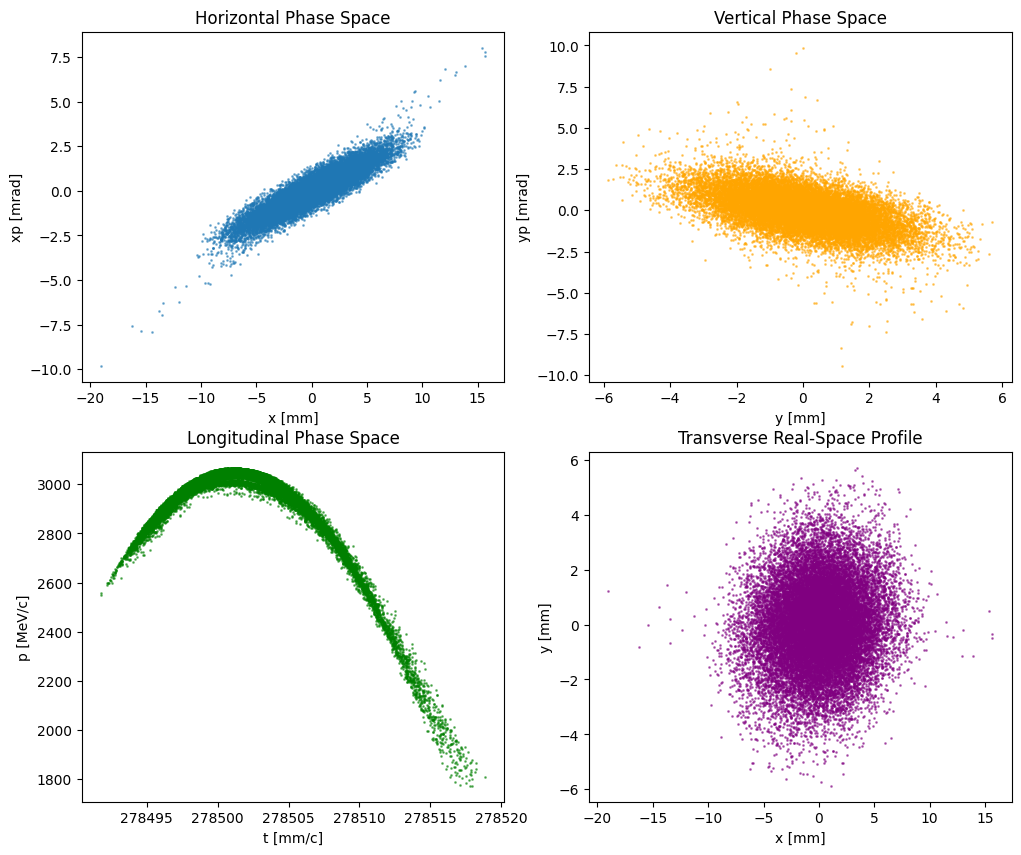

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Horizontal Phase Space
axes[0, 0].scatter(df['x[mm]'], df['xp[mrad]'], s=1, alpha=0.5)
axes[0, 0].set_xlabel('x [mm]')
axes[0, 0].set_ylabel('xp [mrad]')
axes[0, 0].set_title('Horizontal Phase Space')

#Vertical Phase Space
axes[0, 1].scatter(df['y[mm]'], df['yp[mrad]'], s=1, alpha=0.5, color='orange')
axes[0, 1].set_xlabel('y [mm]')
axes[0, 1].set_ylabel('yp [mrad]')
axes[0, 1].set_title('Vertical Phase Space')

#Longitudinal Phase Space
main_bunch = df[df['t[mm/c]'] < 278540]
axes[1, 0].scatter(main_bunch['t[mm/c]'], main_bunch['p[MeV/c]'], s=1, alpha=0.5, color='green')
axes[1, 0].set_xlabel('t [mm/c]')
axes[1, 0].set_ylabel('p [MeV/c]')
axes[1, 0].set_title('Longitudinal Phase Space')

#Transverse Profile
axes[1, 1].scatter(df['x[mm]'], df['y[mm]'], s=1, alpha=0.5, color='purple')
axes[1, 1].set_xlabel('x [mm]')
axes[1, 1].set_ylabel('y [mm]')
axes[1, 1].set_title('Transverse Real-Space Profile')

plt.savefig('phase_space_plots.png')

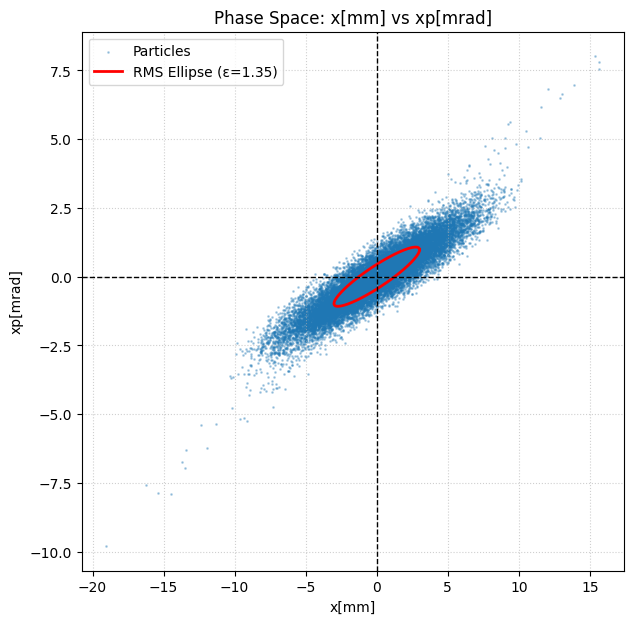

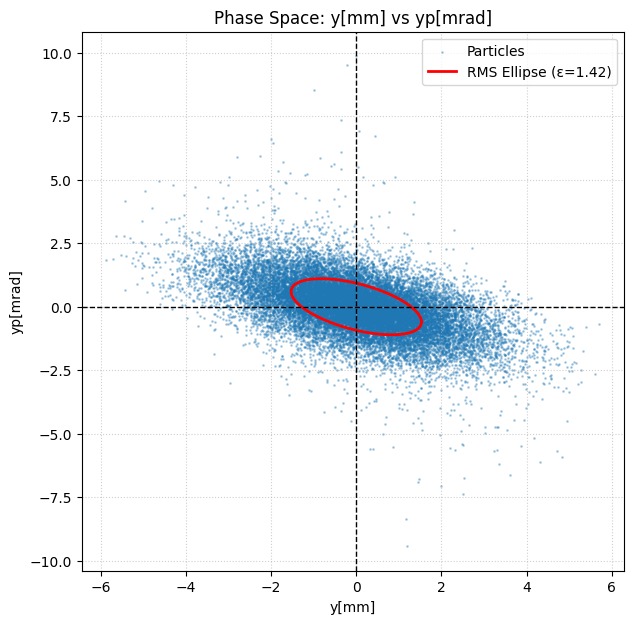

In [33]:

plot_twiss_with_particles(df, 'x[mm]', 'xp[mrad]', ax, bx, emittance_x)
plot_twiss_with_particles(df, 'y[mm]', 'yp[mrad]', ay, by, emittance_y)

In [34]:

# Save twiss results
beam_results = {
    "x": {
        "alpha": float(ax),
        "beta": float(bx),
        "gamma": float(gx),
        "dispersion": float(dx),
        "dispersion_prime": float(ddx),
        "emittance_geo": float(emittance_x)
    },
    "y": {
        "alpha": float(ay),
        "beta": float(by),
        "gamma": float(gy),
        "dispersion": float(dy),
        "dispersion_prime": float(ddy),
        "emittance_geo": float(emittance_y)
    },
    "metadata": {
        "particle_type": "positron",
        "design_energy_mev": 2860.0,
        "n_particles": len(df['ID'])
    }
}

with open('TwissResults.json', 'w') as f:
    json.dump(beam_results, f, indent=4)


Loading line from dict:   0%|          | 0/5296 [00:00<?, ?it/s]

Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           
ColView: name s x px y py zeta delta ptau W_matrix kin_px kin_py kin_ps kin_xprime kin_yprime env_name betx bety alfx alfy gamx gamy dx dpx dy dpy dx_zeta dpx_zeta dy_zeta dpy_zeta betx1 bety1 betx2 bety2 alfx1 alfy1 alfx2 alfy2 gamx1 gamy1 gamx2 gamy2 mux muy muzeta nux nuy nuzeta phix phiy phizeta c_minus_re c_minus_im c_r1 c_r2 c_phi1 c_phi2 dmux dmuy dzeta bx_chrom by_chrom ax_chrom ay_chrom wx_chrom wy_chrom ddx ddpx ddy ddpy
-1.0961681518787994e-11
0.0
-1.0961681518787994e-11
0.0


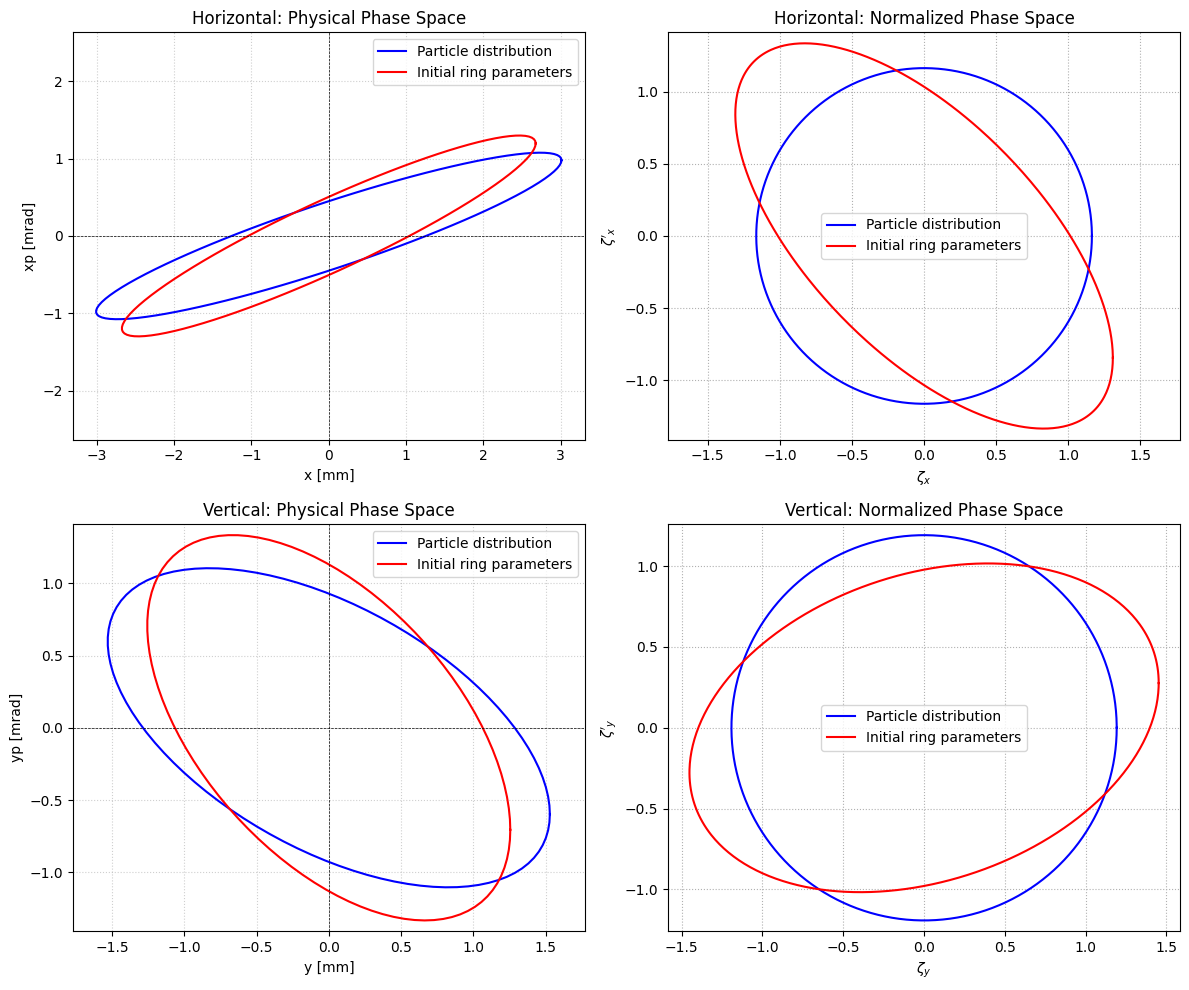

In [35]:
ring=xt.Line.from_json('design_1.json')

#ring twiss values
ring_tw=ring.twiss6d()
print(ring_tw.cols)
# Initial values
initial_twiss = ring_tw.rows[0]

#Horizontal
betx0 = initial_twiss['betx'][0]
alfx0 = initial_twiss['alfx'][0]
dx0   = initial_twiss['dx'][0]
ddx0   = initial_twiss['ddx'][0]
x     = initial_twiss['x'][0]
xp_v    = initial_twiss['px'][0]


#Vertical
bety0 = initial_twiss['bety'][0]
alfy0 = initial_twiss['alfy'][0]
dy0   = initial_twiss['dy'][0]
ddy0   = initial_twiss['ddy'][0]
y     = initial_twiss['y'][0]
yp    = initial_twiss['py'][0]

delta= initial_twiss['delta'][0]

plot_twiss_ellipse(bx,ax,betx0, alfx0, emittance_x,axes[0, 0])
plot_twiss_ellipse(by,ay,bety0, alfy0, emittance_y,axes[1, 0])

plot_twiss_ellipse_normalised(bx*1e-3,ax,betx0, alfx0,dx0,ddx0,delta, emittance_x,axes[0,1])
plot_twiss_ellipse_normalised(by*1e-3,ay,bety0, alfy0,dy0,ddy0,delta, emittance_y,axes[1, 1])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_twiss_ellipse(bx,ax,betx0, alfx0, emittance_x,axes[0, 0])
plot_twiss_ellipse(by,ay,bety0, alfy0, emittance_y,axes[1, 0])

plot_twiss_ellipse_normalised(bx,ax,betx0, alfx0,dx0,ddx0,delta, emittance_x,axes[0,1])
plot_twiss_ellipse_normalised(by,ay,bety0, alfy0,dy0,ddy0,delta, emittance_y,axes[1, 1])

axes[0, 0].set_title("Horizontal: Physical Phase Space")
axes[0, 0].set_xlabel("x [mm]")
axes[0, 0].set_ylabel("xp [mrad]")

axes[0, 1].set_title("Horizontal: Normalized Phase Space")
axes[0, 1].set_xlabel(r"$\zeta_x$")
axes[0, 1].set_ylabel(r"$\zeta'_x$")


axes[1, 0].set_title("Vertical: Physical Phase Space")
axes[1, 0].set_xlabel("y [mm]")
axes[1, 0].set_ylabel("yp [mrad]")

axes[1, 1].set_title("Vertical: Normalized Phase Space")
axes[1, 1].set_xlabel(r"$\zeta_y$")
axes[1, 1].set_ylabel(r"$\zeta'_y$")
plt.xlabel
plt.tight_layout()
plt.savefig('twiss_ellipses.png')
plt.show()


Tracking to turn 1...


Tracking:   0%|          | 0/100 [00:00<?, ?it/s]

Tracking to turn 2000...


Tracking:   0%|          | 0/2000 [00:00<?, ?it/s]

Tracking to turn 4000...


Tracking:   0%|          | 0/2000 [00:00<?, ?it/s]

Tracking to turn 6000...


Tracking:   0%|          | 0/2000 [00:00<?, ?it/s]

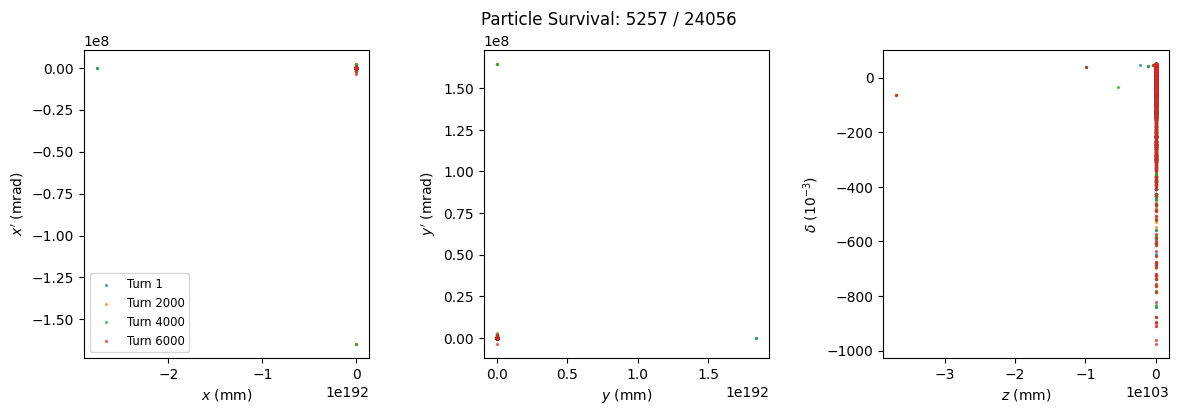

In [36]:
# -------------------------------
# Particle mapping (UNCHANGED)
# -------------------------------

p0c_reference = df['p[MeV/c]'].mean() * 1e6 
ref_particle = xp.Particles(p0c=p0c_reference, mass0=xp.ELECTRON_MASS_EV)

rand_num = 74

# 👉 choose ONE of these:
# df_subset = df.sample(n=500, random_state=rand_num)  # subset
df_subset = df  # all particles

# Coordinates
x = df_subset['x[mm]'].values * 1e-3
y = df_subset['y[mm]'].values * 1e-3
px = df_subset['xp[mrad]'].values * 1e-3
py = df_subset['yp[mrad]'].values * 1e-3

delta = (df_subset['p[MeV/c]'].values * 1e6 - p0c_reference) / p0c_reference

x_matched = x + (dx * delta) 
px_matched = px + (ddx * delta) 
y_matched = y + (dy * delta) 
py_matched = py + (ddy * delta) 

t_mm = df_subset['t[mm/c]'].values
zeta = (np.mean(t_mm) - t_mm) * 1e-3 * ref_particle.beta0[0]

particles = xp.Particles(
    p0c=p0c_reference,
    mass0=xp.ELECTRON_MASS_EV,
    x=x_matched,
    px=px_matched,
    y=y_matched,
    py=py_matched,
    zeta=zeta,
    delta=delta
)

n_track = len(particles.x)

# -------------------------------
# Tracking (FIXED)
# -------------------------------

# Optional multithreading (safe)

ring.discard_tracker()
ring.build_tracker()

ring.configure_radiation(model='quantum')

# Turns to store
trnplt = [1, 2000, 4000, 6000]

stored_data = {}
current_turn = 0

for turn in trnplt:
    print(f"Tracking to turn {turn}...")
    
    ring.track(
        particles,
        num_turns=turn - current_turn,
        with_progress=True
    )
    
    current_turn = turn

    # Store snapshot (lightweight)
    stored_data[turn] = {
        'x': particles.x.copy(),
        'px': particles.px.copy(),
        'y': particles.y.copy(),
        'py': particles.py.copy(),
        'zeta': particles.zeta.copy(),
        'delta': particles.delta.copy(),
    }

# -------------------------------
# Plotting (almost unchanged)
# -------------------------------

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
fig.subplots_adjust(wspace=0.4)

survival_count = np.sum(particles.state > 0)
fig.suptitle(f'Particle Survival: {survival_count} / {n_track}')

labels = [("$x$ (mm)", "$x'$ (mrad)"), 
          ("$y$ (mm)", "$y'$ (mrad)"), 
          ("$z$ (mm)", "$\\delta$ ($10^{-3}$)" )]

for i, (xl, yl) in enumerate(labels):
    ax[i].set_xlabel(xl)
    ax[i].set_ylabel(yl)

for ind, turn in enumerate(trnplt):

    d = stored_data[turn]

    # Horizontal (beta coordinates)
    x_beta = 1000 * (d['x'] - ring_tw.dx[0] * d['delta'])
    px_beta = 1000 * (d['px'] - ring_tw.dpx[0] * d['delta'])

    # (Optional) downsample if too many particles
    if len(x_beta) > 10000:
        mask = np.random.choice(len(x_beta), 10000, replace=False)
    else:
        mask = slice(None)

    ax[0].scatter(x_beta[mask], px_beta[mask], s=2, 
                  color=f'C{ind}', label=f'Turn {turn}', alpha=0.6)

    # Vertical
    ax[1].scatter(1000 * d['y'][mask], 1000 * d['py'][mask], 
                  s=2, color=f'C{ind}', alpha=0.6)

    # Longitudinal
    ax[2].scatter(1000 * d['zeta'][mask], 1000 * d['delta'][mask], 
                  s=2, color=f'C{ind}', alpha=0.6)

ax[0].legend(fontsize='small')

plt.savefig(f'injection_tracking_evolution_{rand_num}_{p0c_reference/1e6}MeV.png')
plt.show()

In [37]:
'''#Particle mapping

#Reference particle
p0c_reference = df['p[MeV/c]'].mean() * 1e6 
#p0c_reference = 3012*1e6

ref_particle = xp.Particles(p0c=p0c_reference, mass0=xp.ELECTRON_MASS_EV)

rand_num=74
n_subset = 500
df_subset = df.sample(n=n_subset, random_state=rand_num)
df_subset=df
#Map coordinates
x = df_subset['x[mm]'].values * 1e-3
y = df_subset['y[mm]'].values * 1e-3
px = df_subset['xp[mrad]'].values * 1e-3
py = df_subset['yp[mrad]'].values * 1e-3

delta = (df_subset['p[MeV/c]'].values * 1e6 - p0c_reference) / p0c_reference

x_matched = (df_subset['x[mm]'].values * 1e-3) + (dx * delta) 
px_matched = (df_subset['xp[mrad]'].values * 1e-3) + (ddx * delta) 

y_matched = (df_subset['y[mm]'].values * 1e-3) + (dy * delta) 
py_matched = (df_subset['yp[mrad]'].values * 1e-3) + (ddy * delta) 

t_mm = df_subset['t[mm/c]'].values
zeta = (np.mean(t_mm) - t_mm) * 1e-3 * ref_particle.beta0[0]

particles = xp.Particles(
    p0c=p0c_reference,
    mass0=xp.ELECTRON_MASS_EV,
    x=x_matched,
    px=px_matched,
    y=y_matched,
    py=py_matched,
    zeta=zeta,
    delta=delta
)'''


"#Particle mapping\n\n#Reference particle\np0c_reference = df['p[MeV/c]'].mean() * 1e6 \n#p0c_reference = 3012*1e6\n\nref_particle = xp.Particles(p0c=p0c_reference, mass0=xp.ELECTRON_MASS_EV)\n\nrand_num=74\nn_subset = 500\ndf_subset = df.sample(n=n_subset, random_state=rand_num)\ndf_subset=df\n#Map coordinates\nx = df_subset['x[mm]'].values * 1e-3\ny = df_subset['y[mm]'].values * 1e-3\npx = df_subset['xp[mrad]'].values * 1e-3\npy = df_subset['yp[mrad]'].values * 1e-3\n\ndelta = (df_subset['p[MeV/c]'].values * 1e6 - p0c_reference) / p0c_reference\n\nx_matched = (df_subset['x[mm]'].values * 1e-3) + (dx * delta) \npx_matched = (df_subset['xp[mrad]'].values * 1e-3) + (ddx * delta) \n\ny_matched = (df_subset['y[mm]'].values * 1e-3) + (dy * delta) \npy_matched = (df_subset['yp[mrad]'].values * 1e-3) + (ddy * delta) \n\nt_mm = df_subset['t[mm/c]'].values\nzeta = (np.mean(t_mm) - t_mm) * 1e-3 * ref_particle.beta0[0]\n\nparticles = xp.Particles(\n    p0c=p0c_reference,\n    mass0=xp.ELECTRON_M

: 

In [38]:
n_track = len(particles.x) 
ring.configure_radiation(model='quantum')
ring.track(particles, num_turns=6100,turn_by_turn_monitor=True, with_progress=True)


data = ring.record_last_track
trnplt = [1, 2000, 4000, 6000]


fig, ax = plt.subplots(1, 3, figsize=(14, 4))
fig.subplots_adjust(wspace=0.4)

survival_count = np.sum(particles.state > 0)
fig.suptitle(f'Particle Survival: {survival_count} / {n_track}')


labels = [("$x$ (mm)", "$x'$ (mrad)"), 
          ("$y$ (mm)", "$y'$ (mrad)"), 
          ("$z$ (mm)", "$\\delta$ ($10^{-3}$)" )]

for i, (xl, yl) in enumerate(labels):
    ax[i].set_xlabel(xl)
    ax[i].set_ylabel(yl)


for ind, turn in enumerate(trnplt):

    x_beta = 1000 * (data.x[:, turn] - ring_tw.dx[0] * data.delta[:, turn])
    px_beta = 1000 * (data.px[:, turn] - ring_tw.dpx[0] * data.delta[:, turn])
    ax[0].scatter(x_beta, px_beta, s=2, color=f'C{ind}', label=f'Turn {turn}', alpha=0.6)
    
    # Vertical
    ax[1].scatter(1000 * data.y[:, turn], 1000 * data.py[:, turn], s=2, color=f'C{ind}', alpha=0.6)
    
    # Longitudinal
    ax[2].scatter(1000 * data.zeta[:, turn], 1000 * data.delta[:, turn], s=2, color=f'C{ind}', alpha=0.6)

ax[0].legend(fontsize='small')


plt.savefig(f'injection_tracking_evolution_{rand_num}_{p0c_reference/1e6}MeV.png')

In [ ]:


turns_to_plot = [0, 1, 2, 3]


fig, axes = plt.subplots(4, 3, figsize=(15, 18))
fig.subplots_adjust(hspace=0.4, wspace=0.35)

col_labels = [
    ("$x$ (mm)", "$x'$ (mrad)"),
    ("$y$ (mm)", "$y'$ (mrad)"),
    ("$\zeta$ (mm)", "$\delta$ ($10^{-3}$)"),
    ("$x$ (mm)", "$y$ (mm)")
]

for row, turn in enumerate(turns_to_plot):
    survived = np.sum(data.state[:, turn] > 0)
    
    axes[row, 0].scatter(data.x[:, turn]*1000, data.px[:, turn]*1000, s=2, color='C0', alpha=0.6)
    axes[row, 0].set_xlabel(col_labels[0][0])
    axes[row, 0].set_ylabel(f"Turn {turn}\n\n{col_labels[0][1]}")
    
    axes[row, 1].scatter(data.y[:, turn]*1000, data.py[:, turn]*1000, s=2, color='C1', alpha=0.6)
    axes[row, 1].set_xlabel(col_labels[1][0])
    axes[row, 1].set_ylabel(col_labels[1][1])
    axes[row, 1].set_title(f"Survivors: {survived}")
    
    axes[row, 2].scatter(data.zeta[:, turn]*1000, data.delta[:, turn]*1000, s=2, color='C2', alpha=0.6)
    axes[row, 2].set_xlabel(col_labels[2][0])
    axes[row, 2].set_ylabel(col_labels[2][1])
    

fig.suptitle(f'Phase Space Evolution at {p0c_reference/1e6:.2f} MeV', fontsize=16, y=0.92)
plt.savefig(f'initial_turns_{rand_num}_{int(p0c_reference/1e6)} MeV.png')
plt.show()

: 

In [ ]:
survival_counts = np.sum(data.state > 0, axis=0)
turns = np.arange(len(survival_counts))

# 2. Plotting
plt.figure(figsize=(10, 6))
plt.plot(turns, survival_counts, color='firebrick', linewidth=2)

plt.title(f'Particle Survival over {len(turns)} Turns', fontsize=14)
plt.xlabel('Turn Number', fontsize=12)
plt.ylabel('Number of Surviving Particles', fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.ylim(min(survival_counts)-5, survival_counts[0]+5)  # Set y-axis to start at 0
plt.legend()


# 3. Save the plot
plt.savefig(f'survival_vs_turns_{int(p0c_reference/1e6)}MeV.png', bbox_inches='tight')
plt.show()

# Print final efficiency
final_efficiency = (survival_counts[-1] / survival_counts[0]) * 100
print(f"Final Survival: {survival_counts[-1]} / {survival_counts[0]} ({final_efficiency:.2f}%)")

: 

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(data.x[:, 0] * 1000, bins=50, color='C0', edgecolor='black', alpha=0.7)
plt.xlabel('$x$ (mm)')
plt.ylabel('Number of Particles')
plt.title(f'Initial Horizontal Distribution - {p0c_reference/1e6:.0f} MeV')
plt.grid(axis='y', alpha=0.3)
plt.savefig(f'initial_x_distribution_{int(p0c_reference/1e6)}MeV.png')
plt.show()

: 

In [ ]:
energy_range_mev = np.linspace(2.8e3, 3.3e3, 100)  
efficiency_results = []


for e_mev in energy_range_mev:
    p0c_test = e_mev * 1e6 
   
    ring.particle_ref = xp.Particles(p0c=p0c_test, mass0=xp.ELECTRON_MASS_EV)
    
    delta_test = (df_subset['p[MeV/c]'].values - e_mev) / e_mev
    

    p_test = xp.Particles(
        p0c=p0c_test,
        mass0=xp.ELECTRON_MASS_EV,
        x=x_matched, px=px_matched,
        y=y_matched, py=py_matched,
        delta=delta_test,
        zeta=zeta
    )
    
   
    ring.track(p_test, num_turns=100)
    
    survived = np.sum(p_test.state > 0)
    efficiency = (survived / len(p_test.x)) * 100
    efficiency_results.append(efficiency)
    
    print(f"Energy: {e_mev:.3f} MeV | Efficiency: {efficiency:.1f}%")

best_idx = np.argmax(efficiency_results)
best_energy = energy_range_mev[best_idx]

p0c_reference = df['p[MeV/c]'].mean() * 1e6 

plt.figure(figsize=(10, 6))
plt.plot(energy_range_mev, efficiency_results, 'o-', color='teal', linewidth=2)
plt.axvline(best_energy, color='red', linestyle='--', label=f'Best: {best_energy:.3f} MeV')
plt.axvline(p0c_reference/1e6, color='blue', linestyle='--', label=f'Avg: {p0c_reference/1e6:.3f} MeV')

plt.title('Injection Efficiency vs. Beam Energy', fontsize=14)
plt.xlabel('Energy [MeV]', fontsize=12)
plt.ylabel('Survival Efficiency [%]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"\nThe best injection efficiency is at {best_energy:.3f} MeV.")

: 

In [ ]:
rand_range = range(1, 51) 
efficiency_results = []
n_particles = 500 
p0c_reference = df['p[MeV/c]'].mean() * 1e6 
fixed_e_mev = p0c_reference / 1e6
ring.particle_ref = xp.Particles(p0c=p0c_reference, mass0=xp.ELECTRON_MASS_EV)

print(f"Starting Random Number Scan at {fixed_e_mev:.2f} MeV...")

for r in rand_range:
    df_subset = df.sample(n=n_particles, random_state=r)
    
    # Re-map coordinates for the new subset
    x_in = df_subset['x[mm]'].values / 1000.0
    px_in = df_subset['xp[mrad]'].values / 1000.0
    y_in = df_subset['y[mm]'].values / 1000.0
    py_in = df_subset['yp[mrad]'].values / 1000.0
    zeta_in = df_subset['t[mm/c]'].values / 1000.0
    delta_in = (df_subset['p[MeV/c]'].values - fixed_e_mev) / fixed_e_mev

    # Apply matching (Assuming ring_tw is already defined)
    x_matched = x_in + ring_tw.dx[0] * delta_in
    px_matched = px_in + ring_tw.dpx[0] * delta_in
    y_matched = y_in + ring_tw.dy[0] * delta_in
    py_matched = py_in + ring_tw.dpy[0] * delta_in

    p_test = xp.Particles(
        p0c=p0c_reference,
        mass0=xp.ELECTRON_MASS_EV,
        x=x_matched, px=px_matched,
        y=y_matched, py=py_matched,
        delta=delta_in,
        zeta=zeta_in
    )

    ring.track(p_test, num_turns=100)
    
    survived = np.sum(p_test.state > 0)
    efficiency = (survived / n_particles) * 100
    efficiency_results.append(efficiency)
    
    print(f"Seed: {r} | Efficiency: {efficiency:.1f}%")

avg_eff = np.mean(efficiency_results)


: 

In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(rand_range, efficiency_results, 'o-', color='purple', linewidth=1.5, markersize=4)
plt.axhline(avg_eff, color='red', linestyle='--', label=f'Average Efficiency: {avg_eff:.1f}%')

plt.title(f'Injection Efficiency vs. Random Seed ({fixed_e_mev:.2f} MeV)', fontsize=14)
plt.xlabel('Random Seed', fontsize=12)
plt.ylabel('Survival Efficiency [%]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(f'efficiency_random_scan_{int(fixed_e_mev)}MeV.png')
plt.show()

print(f"\nScan Complete. Average efficiency across {len(rand_range)} samples: {avg_eff:.2f}%")

: 